# Phonon Density of States of a Mass-Spring Chain

This notebook uses `spectral_density_workflow` to estimate the phonon density of states of a finite one-dimensional mass-spring chain. The dynamical matrix is a discrete spring model, so its eigenvalues are squared mode frequencies and its spectrum contains the vibrational information of the chain.

## Notebook guide

- **Learning objective:** estimate the phonon density of states of a mass-spring chain.
- **Prerequisites:** an editable repository install, the relevant tutorial workflow, and basic spectral linear algebra.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](08_matrix_log_entropy_graph_laplacian.ipynb) · [next](10_thermal_heisenberg_chain.ipynb).


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** A chain of identical masses is coupled by nearest-neighbor springs and weak pinning. Its dynamical matrix is real symmetric and positive definite; the density of its eigenvalues is a finite analogue of a phonon density of states.

**QSVT implementation.** `spectral_density_workflow` fits a Gaussian-window polynomial around each requested energy center, applies those polynomials to the dynamical matrix, and estimates the trace density. The notebook converts the eigenvalue coordinate to angular frequency only for presentation.

**Classical reference and quantum relevance.** Dense diagonalization provides the reference spectrum for this small chain. In a QSVT setting, the same Gaussian spectral windows can be implemented from a block encoding of a sparse dynamical matrix, with trace or state-overlap estimation supplying the density-of-states readout.

## Variable definitions

- $K$ is the mass-normalized dynamical matrix, with diagonal pinning and nearest-neighbor spring terms.
- $\lambda_j$ are the eigenvalues of $K$ and $\omega_j=\sqrt{\lambda_j}$ are the angular phonon frequencies.
- $g_\sigma(\lambda-\lambda_0)=\exp[-(\lambda-\lambda_0)^2/(2\sigma^2)]$ is a Gaussian spectral window.
- $D(\lambda_0)=N^{-1}\operatorname{Tr}[g_\sigma(K-\lambda_0)]$ is the normalized windowed density estimate.
- `degree` is the polynomial degree used for each QSVT-compatible spectral window.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.algorithms import spectral_density_workflow
from qsvt.spectral import eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_masses = 24
spring_constant = 1.0
pinning_constant = 0.08

# Nearest-neighbor springs with fixed-end boundary conditions.
dynamical_matrix = np.zeros((n_masses, n_masses), dtype=float)
for index in range(n_masses):
    dynamical_matrix[index, index] = pinning_constant + 2.0 * spring_constant
    if index > 0:
        dynamical_matrix[index, index - 1] = -spring_constant
    if index + 1 < n_masses:
        dynamical_matrix[index, index + 1] = -spring_constant

eigenvalues, _ = eigh_hermitian(dynamical_matrix)
frequencies = np.sqrt(eigenvalues)
centers = np.linspace(float(eigenvalues[0]), float(eigenvalues[-1]), 80)
width = 0.16
degree = 24

result = spectral_density_workflow(
    dynamical_matrix,
    centers,
    width=width,
    degree=degree,
    num_points=1201,
)

print(f"masses: {n_masses}")
print(f"squared-frequency range: {eigenvalues[0]:.4f} to {eigenvalues[-1]:.4f}")
print(f"frequency range: {frequencies[0]:.4f} to {frequencies[-1]:.4f}")
print(f"polynomial degree: {result.degree}")

masses: 24
squared-frequency range: 0.0958 to 4.0642
frequency range: 0.3095 to 2.0160
polynomial degree: 24


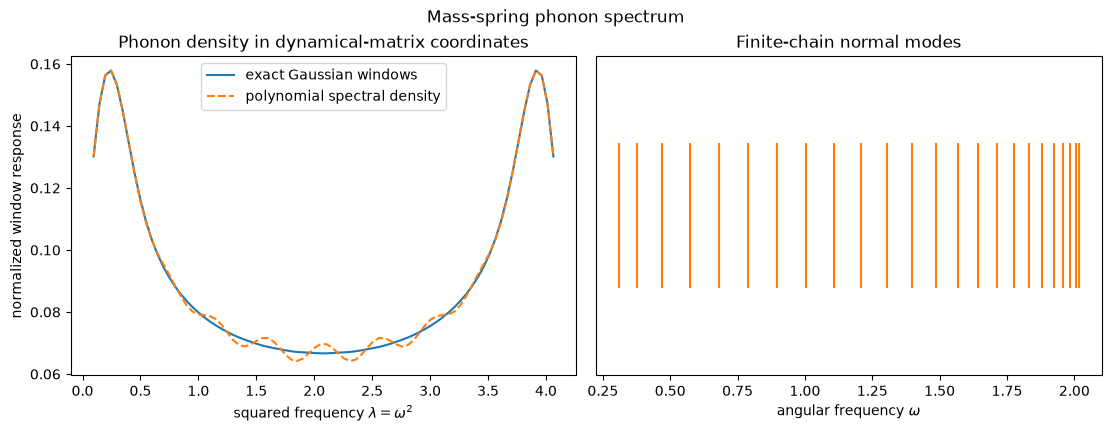

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

axes[0].plot(centers, result.reference_trace_density, label="exact Gaussian windows")
axes[0].plot(centers, result.polynomial_trace_density, "--", label="polynomial spectral density")
axes[0].set_xlabel(r"squared frequency $\lambda=\omega^2$")
axes[0].set_ylabel("normalized window response")
axes[0].set_title("Phonon density in dynamical-matrix coordinates")
axes[0].legend()

axes[1].eventplot(frequencies, orientation="horizontal", colors="tab:orange")
axes[1].set_xlabel(r"angular frequency $\omega$")
axes[1].set_yticks([])
axes[1].set_title("Finite-chain normal modes")
fig.suptitle("Mass-spring phonon spectrum")
plt.show()

In [4]:
report = result.as_report()
assert report["mode"] == "spectral-density-workflow"
assert result.trace_density_error < 0.02
assert np.all(result.reference_trace_density >= 0.0)
assert np.allclose(eigenvalues, np.linalg.eigvalsh(dynamical_matrix))

print(f"trace-density relative error: {result.trace_density_error:.3e}")
print(f"maximum exact window response: {np.max(result.reference_trace_density):.4f}")
print(f"maximum polynomial response: {np.max(result.polynomial_trace_density):.4f}")
print("validation: passed")

trace-density relative error: 1.503e-02
maximum exact window response: 0.1579
maximum polynomial response: 0.1579
validation: passed


## Interpretation and limitations

The plotted density is a normalized Gaussian-window response rather than a thermodynamic-limit density or a directly sampled quantum measurement. The dynamical matrix is a small dense representation of a sparse physical model, and the notebook validates the polynomial transform against exact diagonalization. Scaling to larger lattices would require an explicit sparse block encoding and a trace-estimation strategy.

## Takeaways and next steps

- **Result:** The workflow shows how to estimate the phonon density of states of a mass-spring chain.
- **Interpretation boundary:** This is a finite, simulator-scale application client; input, readout, and scalability assumptions remain explicit.
- **Continue:** [collection index](README.md) · [previous](08_matrix_log_entropy_graph_laplacian.ipynb) · [next](10_thermal_heisenberg_chain.ipynb).
